[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MohamedEshmawy/langchain-handbook-gemini/blob/main/xx-langchain-chunking.ipynb) [![Open nbviewer](https://raw.githubusercontent.com/pinecone-io/examples/master/assets/nbviewer-shield.svg)](https://nbviewer.org/github/MohamedEshmawy/langchain-handbook-gemini/blob/main/xx-langchain-chunking.ipynb)

#### [LangChain Handbook](https://pinecone.io/learn/langchain)

# Preparing Text Data for use with Retrieval-Augmented LLMs

In this walkthrough we'll take a look at an example and some of the considerations when we need to prepare text data for retrieval augmented question-answering using **L**arge **L**anguage **M**odels (LLMs).

## Required Libraries

There are a few Python libraries we must `pip install` for this notebook to run, those are:

In [1]:
# Use %pip (not !pip) so packages install into THIS notebook's kernel,
# not some other Python on your system. Restart the kernel after this runs.
%pip install -qU \
    langchain==0.3.25 \
    langchain-community==0.3.25 \
    tiktoken==0.9.0 \
    datasets \
    sniffio anyio pyparsing

# --- OpenRouter / OpenAI alternative (for reference, not needed here) ---
# This is a pure text-chunking lesson, so no LLM or embedding API key is required.
# %pip install -qU langchain-openai==0.3.22

Note: you may need to restart the kernel to use updated packages.


## Preparing Data

For a chunking demo we just need some real text to split. We'll load a small, public Hugging Face dataset of finance-related Reddit posts. Each record has a `selftext` field (the body of the post), and several posts are long enough to show off chunking nicely. This is fully reproducible - the dataset downloads automatically, so the notebook runs anywhere with no scraping step.

In [2]:
from datasets import load_dataset

data = load_dataset(
    "aurelio-ai/reddit-finance",
    split="train",
)
data

Dataset({
    features: ['id', 'subreddit', 'title', 'selftext'],
    num_rows: 107
})

We now wrap each record in a LangChain `Document`. The `page_content` is the post body (`selftext`) and we keep a little metadata (a `source` URL and the subreddit) so we can trace each chunk back to where it came from. Using `Document` objects mirrors what every LangChain loader returns, so the chunking code below is identical to what you'd write against a real loader.

In [3]:
from langchain.schema import Document

docs = [
    Document(
        page_content=record["selftext"],
        metadata={
            "source": f"https://reddit.com/r/{record['subreddit']}/comments/{record['id']}",
            "subreddit": record["subreddit"],
            "title": record["title"],
        },
    )
    # skip any empty posts so every Document has real text to chunk
    for record in data if record["selftext"].strip()
]
len(docs)

100

Let's take a look at the format each `Document` contains:

In [4]:
docs[0]

Document(metadata={'source': 'https://reddit.com/r/stocks/comments/1j0w73o', 'subreddit': 'stocks', 'title': 'Rate My Portfolio - r/Stocks Quarterly Thread March 2025'}, page_content="Please use this thread to discuss your portfolio, learn of other stock tickers &amp; portfolios like [Warren Buffet's](https://buffett.online/en/portfolio/), and help out users by giving constructive criticism.\n\nWhy quarterly?  Public companies report earnings quarterly; many investors take this as an opportunity to rebalance their portfolios.  We highly recommend you do some reading:  Check out our wiki's list of [relevant posts &amp; book recommendations.](https://www.reddit.com/r/stocks/wiki/index/#wiki_relevant_posts.2C_books.2C_wiki_recommendations)\n\nYou can find stocks on your own by using a scanner like your broker's or [Finviz.](https://finviz.com/screener.ashx)  To help further, here's a list of [relevant websites.](https://www.reddit.com/r/stocks/wiki/index/#wiki_relevant_websites.2Fapps)\n\

We access the plaintext page content like so:

In [5]:
print(docs[0].page_content)

Please use this thread to discuss your portfolio, learn of other stock tickers &amp; portfolios like [Warren Buffet's](https://buffett.online/en/portfolio/), and help out users by giving constructive criticism.

Why quarterly?  Public companies report earnings quarterly; many investors take this as an opportunity to rebalance their portfolios.  We highly recommend you do some reading:  Check out our wiki's list of [relevant posts &amp; book recommendations.](https://www.reddit.com/r/stocks/wiki/index/#wiki_relevant_posts.2C_books.2C_wiki_recommendations)

You can find stocks on your own by using a scanner like your broker's or [Finviz.](https://finviz.com/screener.ashx)  To help further, here's a list of [relevant websites.](https://www.reddit.com/r/stocks/wiki/index/#wiki_relevant_websites.2Fapps)

If you don't have a broker yet, see our [list of brokers](https://www.reddit.com/r/stocks/wiki/index/#wiki_brokers_for_investing) or search old posts.  If you haven't started investing or t

In [6]:
print(docs[5].page_content)

Alphabet reported Thursday that Waymo, its autonomous vehicle unit, is now delivering more than 250,000 paid robotaxi rides per week in the U.S.

CEO Sundar Pichai said Waymo has options in terms of “business models across geographies,” and the robotaxi company is building partnerships with ride-hailing app Uber, automakers and operations and maintenance businesses that tend to its vehicle fleets.

“We can’t possibly do it all ourselves,” said Pichai on a call with analysts for Alphabet’s first-quarter earnings. 

Pichai noted that Waymo has not entirely defined its long-term business model, and there is “future optionality around personal ownership” of vehicles equipped with Waymo’s self-driving technology. The company is also exploring the ways it can scale up its operations, he said.

The 250,000 paid rides per week are up from 200,000 in February, before Waymo opened in Austin and expanded in the San Francisco Bay Area in March. 

Waymo, which is part of Alphabet’s Other Bets segme

We can also find the source of each document:

In [7]:
docs[5].metadata['source']

'https://reddit.com/r/stocks/comments/1k7782l'

Before chunking, it helps to look at how *long* each document is - not in characters, but in **tokens**, since tokens are the unit LLMs and embedding models actually consume.

To count tokens offline we use `tiktoken`. It runs entirely locally (no API calls). `tiktoken` is OpenAI's BPE tokenizer, so it isn't *exactly* Gemini's tokenizer, but both are sub-word BPE tokenizers and their token counts are close - close enough to size chunks sensibly, and far more accurate than counting raw characters. We use the modern `o200k_base` encoding.

In [8]:
import tiktoken

# o200k_base is a modern tiktoken encoding. tiktoken runs locally (no API calls).
tokenizer = tiktoken.get_encoding('o200k_base')

# create the length function
def tiktoken_len(text):
    tokens = tokenizer.encode(
        text,
        disallowed_special=()
    )
    return len(tokens)

We defined the encoder as `"o200k_base"`. This is one of the tokenizers shipped with `tiktoken` and is a good general-purpose, fully-offline approximation for sizing text into chunks. Remember that a different model family (e.g. Gemini) uses its own tokenizer, so treat these counts as a close estimate rather than an exact match for any one model.

You can list the encodings that ship with `tiktoken` like so:

In [9]:
tiktoken.list_encoding_names()

['gpt2', 'r50k_base', 'p50k_base', 'p50k_edit', 'cl100k_base', 'o200k_base']

Using the `tiktoken_len` function, let's count and visualize the number of tokens across our documents.

In [10]:
token_counts = [tiktoken_len(doc.page_content) for doc in docs]

Let's see `min`, average, and `max` values:

In [11]:
print(f"""Min: {min(token_counts)}
Avg: {int(sum(token_counts) / len(token_counts))}
Max: {max(token_counts)}""")

Min: 7
Avg: 302
Max: 1657


Now visualize:

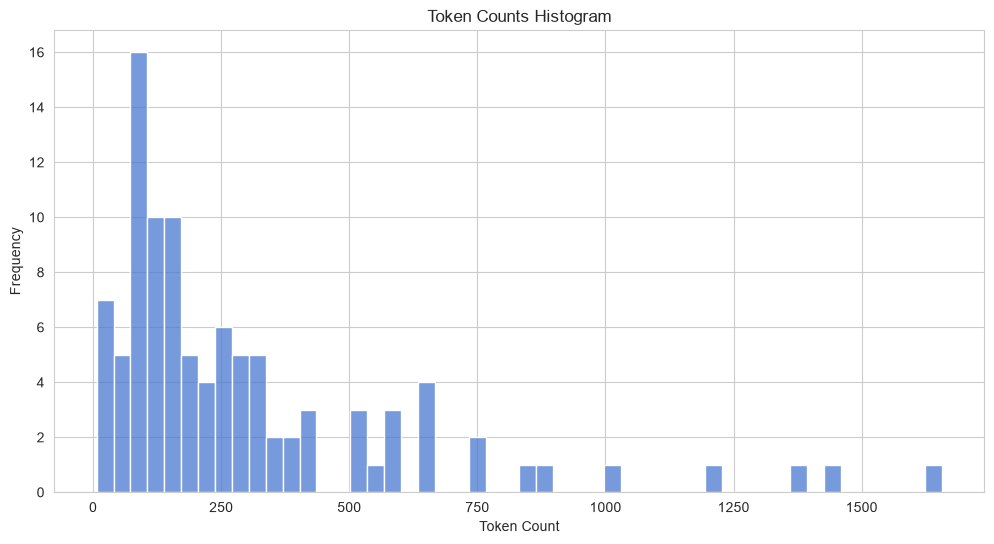

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# set style and color palette for the plot
sns.set_style("whitegrid")
sns.set_palette("muted")

# create histogram
plt.figure(figsize=(12, 6))
sns.histplot(token_counts, kde=False, bins=50)

# customize the plot info
plt.title("Token Counts Histogram")
plt.xlabel("Token Count")
plt.ylabel("Frequency")

plt.show()

The vast majority of pages seem to contain a lower number of tokens. But our limits for the number of tokens to add to each chunk is actually smaller than some of the smaller pages. But, how do we decide what this number should be?

### Chunking the Text

When we later retrieve text to feed an LLM, we don't want to hand it an entire document - we want small, focused passages. Smaller chunks embed more precisely, and at query time retrieval can return just the relevant passage instead of a whole post.

A common target is to keep each chunk to a few hundred tokens so that several chunks comfortably fit inside a prompt alongside the question and the model's answer. Here we'll aim for a max of **400** tokens per chunk.

To create these chunks we use the `RecursiveCharacterTextSplitter` from LangChain. The *recursive* part splits on natural boundaries first (paragraphs, then lines, then spaces). The word "Character" in the class name refers to *how it splits*, not how it *measures* size. By building the splitter with `from_tiktoken_encoder(...)` we tell it to size chunks by **token count** (via the offline `tiktoken` tokenizer) rather than by character count.

We initialize our `RecursiveCharacterTextSplitter` like so:

In [13]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="o200k_base",
    chunk_size=400,       # max tokens per chunk
    chunk_overlap=20,     # number of tokens overlap between chunks
    separators=["\n\n", "\n", " ", ""]
)

Then we split the text for a (long) document like so:

In [14]:
# find a nice long document to demonstrate splitting into several chunks
long_idx = max(range(len(docs)), key=lambda i: tiktoken_len(docs[i].page_content))
chunks = text_splitter.split_text(docs[long_idx].page_content)
len(chunks)

6

In [15]:
[tiktoken_len(chunk) for chunk in chunks]

[229, 301, 385, 273, 238, 239]

Each of those chunks sits at or below our 400-token target, with a small overlap carried between consecutive chunks.

That was for a single document. We need to do this over all of our documents. While we iterate through the docs to create these chunks we will reformat them into a structure that looks like:

```json
[
    {
        "id": "abc-0",
        "text": "some important document text",
        "source": "https://reddit.com/r/stocks/comments/abc"
    },
    {
        "id": "abc-1",
        "text": "the next chunk of important document text",
        "source": "https://reddit.com/r/stocks/comments/abc"
    }
    ...
]
```

The `"id"` will be created based on the `source` URL of the text + its chunk number.

In [16]:
import hashlib

url = docs[long_idx].metadata['source']
print(url)

# convert URL to a unique ID
m = hashlib.md5()
m.update(url.encode('utf-8'))
uid = m.hexdigest()[:12]
print(uid)

https://reddit.com/r/pennystocks/comments/1k6ua11
6e2613938e06


Then use the `uid` alongside chunk number and actual `url` to create the format needed:

In [17]:
data = [
    {
        'id': f'{uid}-{i}',
        'text': chunk,
        'source': url
    } for i, chunk in enumerate(chunks)
]
data

[{'id': '6e2613938e06-0',
  'text': '[$FDXTF](https://x.com/search?q=%24FDXTF&amp;src=cashtag_click) FendX Enters into an Exclusive Supply Agreement and Signs Exclusive IP License Agreement with Scott Smith and US BioSolutions  \n[https://newsfilecorp.com/release/249597](https://www.newsfilecorp.com/release/249597)\n\n# April 24, 2025 8:00 AM EDT | Source:\xa0[FendX Technologies Inc.](https://www.newsfilecorp.com/company/9526/FendX-Technologies-Inc.)\n\n* **Signing the Supply Agreement enables FendX to create a differentiated finished line of sponge products for sale and distribution in consumer, retail and other commercial cleaning markets worldwide.**\n* **Eco-friendly sponge will offer a sustainable alternative to traditional sponges by being washable, reuseable and biodegradable, resistant to bacterial growth and free of toxic plasticizers.**\n* **North American household cleaner sponge market, alone, valued at US$1.96 billion in 2024 and projected to attain US$2.92 billion by 2033

Now we repeat the same logic across our full dataset:

In [18]:
from tqdm.auto import tqdm

documents = []

for doc in tqdm(docs):
    url = doc.metadata['source']
    m = hashlib.md5()
    m.update(url.encode('utf-8'))
    uid = m.hexdigest()[:12]
    chunks = text_splitter.split_text(doc.page_content)
    for i, chunk in enumerate(chunks):
        documents.append({
            'id': f'{uid}-{i}',
            'text': chunk,
            'source': url
        })

len(documents)

  0%|          | 0/100 [00:00<?, ?it/s]

139

We're now left with a flat list of chunk records. We can save them to a JSON lines (`.jsonl`) file like so:

In [19]:
import json

with open('train.jsonl', 'w') as f:
    for doc in documents:
        f.write(json.dumps(doc) + '\n')

To load the data from file we'd write:

In [20]:
documents = []

with open('train.jsonl', 'r') as f:
    for line in f:
        documents.append(json.loads(line))

len(documents)

139

In [21]:
documents[0]

{'id': '20e1c47e8d4f-0',
 'text': "Please use this thread to discuss your portfolio, learn of other stock tickers &amp; portfolios like [Warren Buffet's](https://buffett.online/en/portfolio/), and help out users by giving constructive criticism.\n\nWhy quarterly?  Public companies report earnings quarterly; many investors take this as an opportunity to rebalance their portfolios.  We highly recommend you do some reading:  Check out our wiki's list of [relevant posts &amp; book recommendations.](https://www.reddit.com/r/stocks/wiki/index/#wiki_relevant_posts.2C_books.2C_wiki_recommendations)\n\nYou can find stocks on your own by using a scanner like your broker's or [Finviz.](https://finviz.com/screener.ashx)  To help further, here's a list of [relevant websites.](https://www.reddit.com/r/stocks/wiki/index/#wiki_relevant_websites.2Fapps)\n\nIf you don't have a broker yet, see our [list of brokers](https://www.reddit.com/r/stocks/wiki/index/#wiki_brokers_for_investing) or search old post

### (Optional) Sharing the Dataset

We've now created our dataset and you can go ahead and use it in any way you like. However, if you'd like to share the dataset, or store it somewhere that you can get easy access to later - we can use [Hugging Face Datasets Hub](https://huggingface.co/datasets).

To begin we first need to create an account by clicking the **Sign Up** button at [huggingface.co](https://huggingface.co/). Once done we click our profile button in the same location > click **New Dataset** > give it a name like *"langchain-docs"* > set the dataset to **Public** or **Private** > click **Create dataset**.